# Imports

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import genextreme
from scipy.stats import weibull_minS

# Variables

In [27]:
# C, material const., calibrated experimentally
# set values to calibrate C
stress_amp = 100        # stress amplitude
defect_size = 100       # defect size
N_target = 1e5          # target N for these values        
m = 2.7                 # sensitivity to stress
n = 1.5                 # sensitivity to defect size, = nn.Parameter(torch.tensor(1.5))

# calibrate C given these values
C = N_target * (stress_amp**m) * (defect_size**n)

In [28]:
# define constants
mu = 3              # mean of log
sigma = 1           # std dev of log
Y = 1.0             # geometry factor

# define variables
n_defects = 1000    # size of random dataset
defect_size = np.linspace(start=20, stop=600, num=n_defects)     # surface area of defect, A, [mm^2]
stress_amp = np.linspace(start=50, stop=500, num=n_defects)      # stress amplitude [MPa]

# Functions

## Data

Defect data is generated randomly based on lognormal distribution.

In [29]:
# define fxn to generate defects based on a lognormal distribution
def generate_defects(n_defects, mu, sigma):
    return np.random.lognormal(mu,           # mean of logarithm 
                               sigma,        # std dev
                               n_defects)    # no. of random samples generated

# generate n_defects random defects
defects = generate_defects(n_defects, mu, sigma)

### Histogram

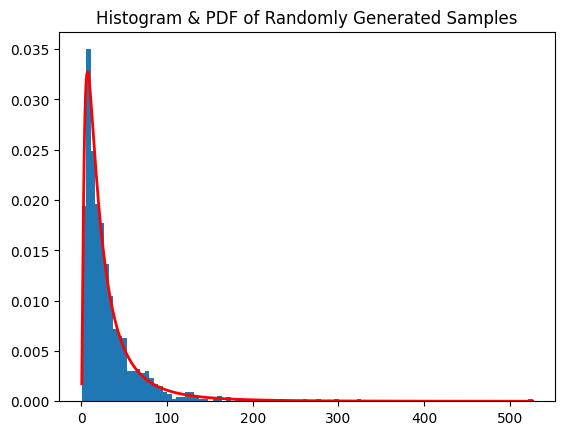

In [30]:
# show histogram and probability density fxn of randomly generated samples
count, bins, ignored = plt.hist(defects,
                                bins=100,
                                density=True,
                                align='mid')

x = np.linspace(min(bins), max(bins), n_defects)
pdf = (np.exp(-(np.log(x)-mu)**2/(2*sigma**2))
       /(x*sigma*np.sqrt(2*np.pi)))


# axis labels
plt.title('Histogram & PDF of Randomly Generated Samples')

plt.plot(x, pdf, linewidth=2, color='r')
plt.axis('tight')
plt.show()

### Generalized Extreme Value Distribution (GEV)
- each specimen contains many defects
- fatigue failure is governed by the largest critical defect
- so the distribution of maxima tends toward a GEV distribution

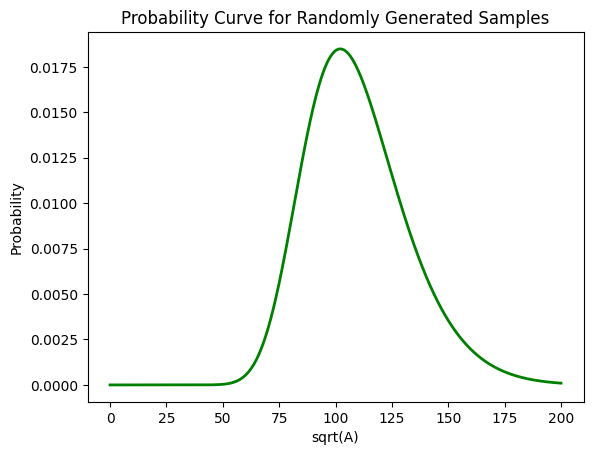

In [31]:
# generate random extreme values
samples = genextreme.rvs(c=0.1,             # shape parameter
                         loc=100,           # center/location
                         scale=20,          # spread
                         size=n_defects)

# calculate pdf
x2 = np.linspace(0, 200, n_defects)
pdf2 = genextreme.pdf(x2, c=0.1, loc=100, scale=20)

# axis labels
plt.title('Probability Curve for Randomly Generated Samples')
plt.xlabel('sqrt(A)')
plt.ylabel('Probability')

plt.plot(x2, pdf2, linewidth=2, color='g')
plt.axis('tight')
plt.show()

## Critical Defects
The critical defect is the one that leads to failure. Assume this is the largest defect.

The critical (max) defect is found.

In [32]:
# define fxn to select the crtical defect
def critical_defect(defects):
    # defect that dominates fatigue failure = max defect
    return np.max(defects)

# calculate the critical defect size
A_crit = critical_defect(defects)
print("The critical (max) defect size is",A_crit)

The critical (max) defect size is 526.5029018345238


## Fatigue Life

Fatigue life or the number of cycles, N, is determined based on,

**N = C / (stress_amp^m * A^n)**

In [33]:
# define fxn to find the fatigue life, N, based on the given parameters
def fatigue_life(stress_amp, defect_size, C, m, n):
    return C / ((stress_amp**m) * (defect_size**n))

## Shiozawa Model

The stress intensity factor, delta(K), the measure of the severity of a crack situation, is determined by

**delta(K) = Y * stress_amp * sqrt(pi * A)**

Assume the defect_size is the crack length: defect_size, A = crack_length, a

In [34]:
# define function to compute stress intensity factor, delta(K)
def stress_intensity_factor(stress_amp, defect_size):
    return Y * stress_amp * np.sqrt(np.pi * defect_size)

# Monte Carlo Loop

simulate randomness many times

Each specimen has random defects. So:
- n_defects number of virtual specimens is generated
- each specimen gets random defects
- the critical defect is calculated for each
- the distribution of fatigue lives is predicted
- the life distribution is observed

## Fixed Stress

In [35]:
# set fixed stress amplitude, S, [MPa]
S_fixed = 250

# list to store results
lives = []          # list to store fatigue lives
M = []              # list to store Murakami parameter
max_defects = []    # list to store max defects
K = []              # list to store stress intensity factors

for i in range(1000):
    defects = generate_defects(n_defects, mu, sigma)
    
    A_crit = critical_defect(defects)
    N = fatigue_life(S_fixed, A_crit, C, m, n)
    Murakami = np.sqrt(A_crit)     # Murakami parameter for defect size, sqrt(A)
    delta_K = stress_intensity_factor(S_fixed, A_crit)
    
    # store results in lists
    lives.append(N)
    M.append(Murakami)
    max_defects.append(np.max(defects))
    K.append(delta_K)
    

### Fatigue Life

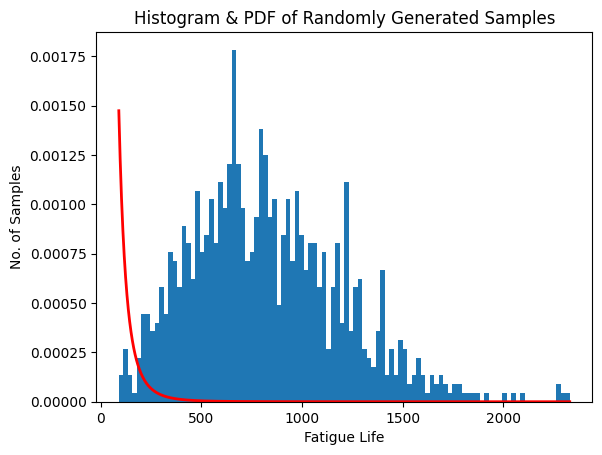

In [36]:
# plot fatigue life histogram
count, bins, ignored = plt.hist(lives,
                                bins=100,
                                density=True,
                                align='mid')

x1 = np.linspace(min(bins), max(bins), n_defects)
pdf1 = (np.exp(-(np.log(x1)-mu)**2/(2*sigma**2))
       /(x1*sigma*np.sqrt(2*np.pi)))

# axis labels
plt.title('Histogram & PDF of Randomly Generated Samples')
plt.xlabel('Fatigue Life')
plt.ylabel('No. of Samples')

plt.plot(x1, pdf1, linewidth=2, color='r')
plt.axis('tight')
plt.show()

In [37]:
# mean fatigue life
N_avg = np.mean(lives)

# std dev of faigue life
N_sigma = np.std(lives)

print("The average fatigue life is", N_avg)
print("The standard deviation of the fatigue life is", N_sigma)

The average fatigue life is 825.0825285956942
The standard deviation of the fatigue life is 376.6912462478079


### GEV, P vs sqrt(A)
- each specimen contains many defects
- fatigue failure is governed by the largest critical defect
- so the distribution of maxima tends toward a GEV distribution

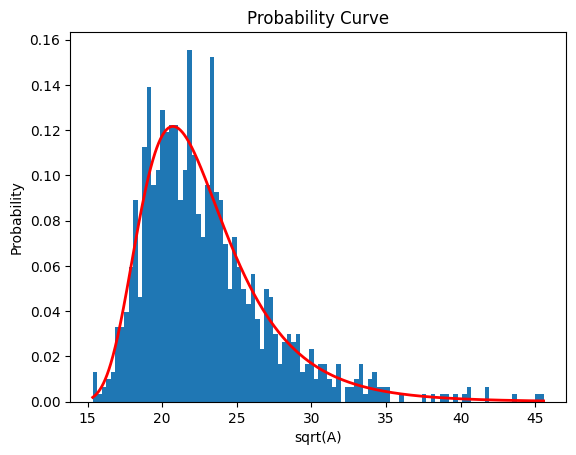

In [38]:
# failure probability, P vs sqrt(defect_size)
c, loc, scale = genextreme.fit(M)

# show histogram and probability density fxn
count, bins, ignored = plt.hist(M,
                                bins=100,
                                density=True,
                                align='mid')

# calculate pdf
x3 = np.linspace(min(M), max(M), n_defects)
pdf3 = genextreme.pdf(x3, c, loc, scale)

# axis labels
plt.title('Probability Curve')
plt.xlabel('sqrt(A)')
plt.ylabel('Probability')

plt.plot(x3, pdf3, linewidth=2, color='r')
plt.axis('tight')
plt.show()

### Shiozawa Curve

Shiozawa: stress intensity factor, delta(K), at the critical defect vs. sqrt(A)

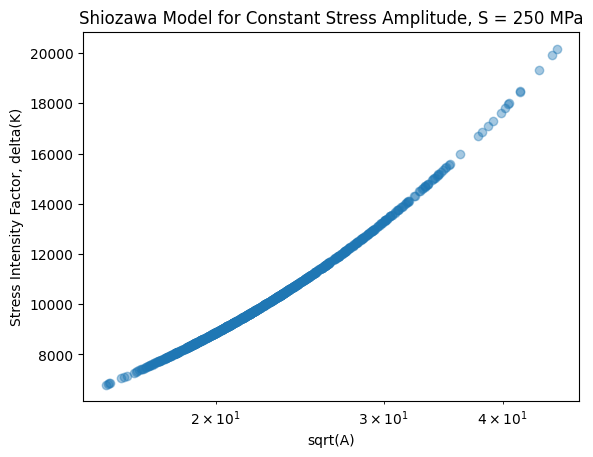

In [39]:
# scatter plot of delta(K) vs sqrt(A)
plt.scatter(M, K, alpha=0.4)
plt.xscale('log')

# axis labels
plt.title('Shiozawa Model for Constant Stress Amplitude, S = 250 MPa')
plt.xlabel('sqrt(A)')
plt.ylabel('Stress Intensity Factor, delta(K)')

plt.show()

Under constant stress, as the size of the defect increases, the stress intensity factor increases.

#### Confidence Intervals

In [40]:
logM = np.log10(M)

# create bins for logM
bins = np.linspace(min(logM), max(logM), 20)

# calculate mean and std dev of stress values in each bin
K_avg = []
K_std = []
centers = []

for i in range(len(bins) - 1):
    mask = (logM >= bins[i]) & (logM < bins[i+1])
    Ks_in_bin = np.array(K)[mask]

    if Ks_in_bin.size == 0:
        continue
    
    K_avg.append(np.mean(Ks_in_bin))
    K_std.append(np.std(Ks_in_bin))
    centers.append(0.5 * (bins[i] + bins[i+1]))

K_avg = np.array(K_avg)
K_std = np.array(K_std)
centers = np.array(centers)

# confidence intervals, assume 96% CI
upper_K = K_avg + 1.96 * K_std
lower_K = K_avg - 1.96 * K_std

upper = np.array(upper_K)
lower = np.array(lower_K)

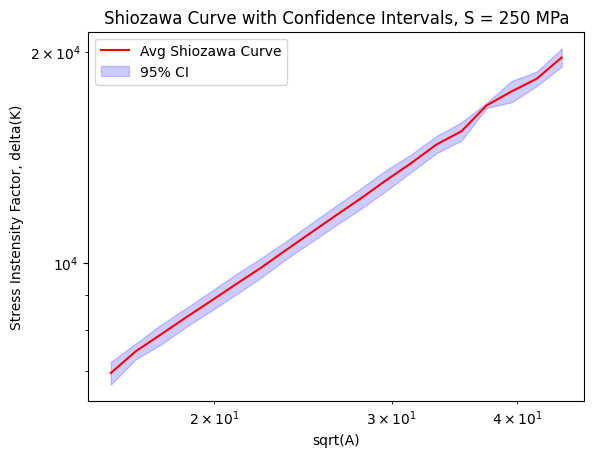

In [41]:
xvals1 = np.power(10, centers)

plt.plot(xvals1, K_avg, 'red', label='Avg Shiozawa Curve')

plt.fill_between(xvals1, lower_K, upper_K,
                 color='blue',
                 alpha=0.2,
                 label='95% CI')

plt.xscale('log')
plt.yscale('log')

# axis labels
plt.title('Shiozawa Curve with Confidence Intervals, S = 250 MPa')
plt.xlabel('sqrt(A)')
plt.ylabel('Stress Instensity Factor, delta(K)')

plt.legend()
plt.show()

The narrow confidence intervals imply a good certainty in the estimate.

### Reliability Curves
the probability a specimen survives beyond a given 

fraction of specimens that survive past N cycles:

**R(N) = P(N_f > N)**

In [42]:
# sort fatigue lives
lives_sorted = np.sort(np.array(lives))

# calculate survival probability
j = len(lives_sorted)
R = 1 - np.arange(j) / j

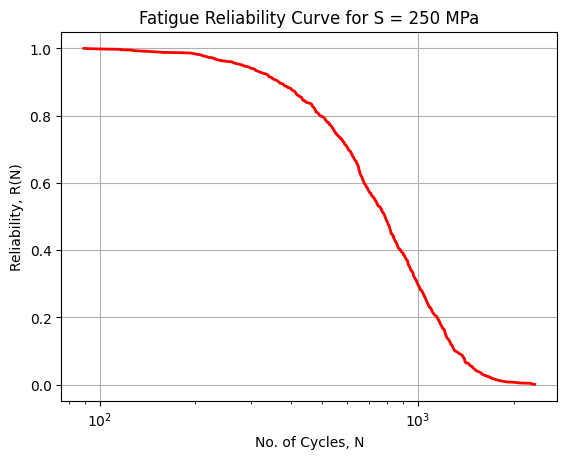

In [43]:
# plot reliability curve
plt.plot(lives_sorted, R,
         color='red',
         linewidth=2,
         label='Monte Carlo')
plt.xscale("log")

# axis labels
plt.title("Fatigue Reliability Curve for S = 250 MPa")
plt.xlabel("No. of Cycles, N")
plt.ylabel("Reliability, R(N)")

plt.grid()
plt.show()

#### Weibull Reliability Model
R(N) = exp[-(N/eta)^beta]

In [44]:
# estimate weibull parameters from generated data
shape, loc, scale = weibull_min.fit(lives, floc=0)

# calculate theoretical reliability based on estimated weibull parameters
N_vals = np.linspace(min(lives), max(lives), 200)
R_theory = np.exp(-(N_vals / scale)**shape)

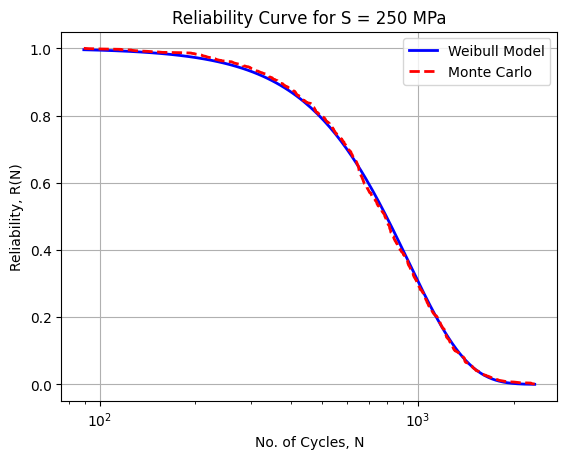

In [45]:
# plot theoretical reliability curve
plt.plot(N_vals, R_theory,
         color="blue",
         linewidth=2,
         label="Weibull Model")

# plot empirical reliability curve
lives_sorted = np.sort(lives)
R_emp = 1 - np.arange(len(lives)) / len(lives)

plt.plot(lives_sorted, R_emp,
         linestyle="--",
         color="red",
         linewidth=2,
         label="Monte Carlo")

# axis labels
plt.title("Reliability Curve for S = 250 MPa")
plt.xlabel("No. of Cycles, N")
plt.ylabel("Reliability, R(N)")

plt.xscale("log")
plt.legend()
plt.grid()
plt.show()

Since the Weibull reliability curve and the Monte Carlo reliability curve are very close, the probabilistic model is internally consistent and the Weibull approximation is describing the failure behavior well.

## Varying Sress

### Shiowaza Curve

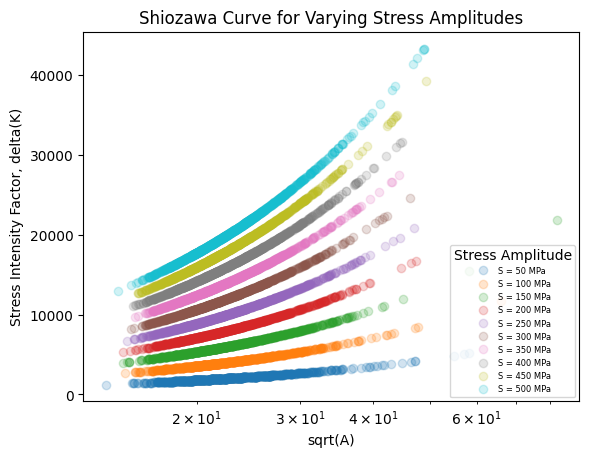

In [46]:
# vary stress amplitude, S
S_vals = [50, 100, 150, 200, 250, 300, 350, 400, 450, 500]

for S_i in S_vals:

    # temporary lists for this stress amplitude
    M_temp = []
    K_temp = []
    lives_temp = []
    max_defects_temp = []

    for i in range(1000):
        defects = generate_defects(n_defects, mu, sigma)

        A_crit1 = critical_defect(defects)
        Murakami1 = np.sqrt(A_crit1)
        delta_K1 = stress_intensity_factor(S_i, A_crit1)
        N1 = fatigue_life(S_i, A_crit1, C, m, n)

        # store points for this stress amplitude
        M_temp.append(Murakami1)
        K_temp.append(delta_K1)
        lives_temp.append(N1)
        max_defects_temp.append(np.max(defects))

    # plot all points for this stress amplitude
    plt.plot(M_temp, K_temp, 'o', alpha=0.2, label=f'S = {S_i} MPa')

# axis labels
plt.title('Shiozawa Curve for Varying Stress Amplitudes')
plt.xlabel('sqrt(A)')
plt.ylabel('Stress Intensity Factor, delta(K)')

plt.xscale('log')

plt.legend(title='Stress Amplitude', fontsize=6, loc='lower right')
plt.show()

A higher stress amplitude results in a higher stress intensity factor and stronger Shiowaza curve.
As the stress amplitudes become much smaller, the curve becomes almost linear.

### Reliability Curves
the probability a specimen survives beyond a given life

fraction of specimens that survive past N cycles:

**R(N) = P(N_f > N)**

In [47]:
# sort fatigue lives
lives_sorted1 = np.sort(np.array(lives_temp))

# calculate survival probability
j1 = len(lives_sorted1)
R1 = 1 - np.arange(j1) / j1

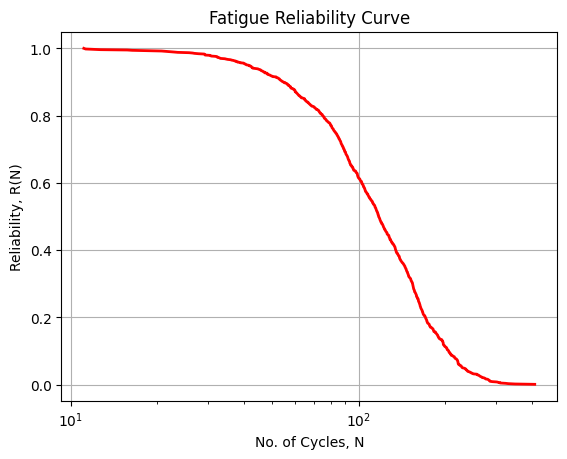

In [48]:
# plot reliability curve
plt.plot(lives_sorted1, R1,
         color='red',
         linewidth=2,
         label='Monte Carlo')
plt.xscale("log")

# axis labels
plt.title("Fatigue Reliability Curve")
plt.xlabel("No. of Cycles, N")
plt.ylabel("Reliability, R(N)")

plt.grid()
plt.show()

#### Weibull Reliability Model
R(N) = exp[-(N/eta)^beta]

In [49]:
# estimate weibull parameters from generated data
shape, loc, scale = weibull_min.fit(lives_temp, floc=0)

# calculate theoretical reliability based on estimated weibull parameters
N_vals1 = np.linspace(min(lives_temp), max(lives_temp), 200)
R_theory1 = np.exp(-(N_vals1 / scale)**shape)

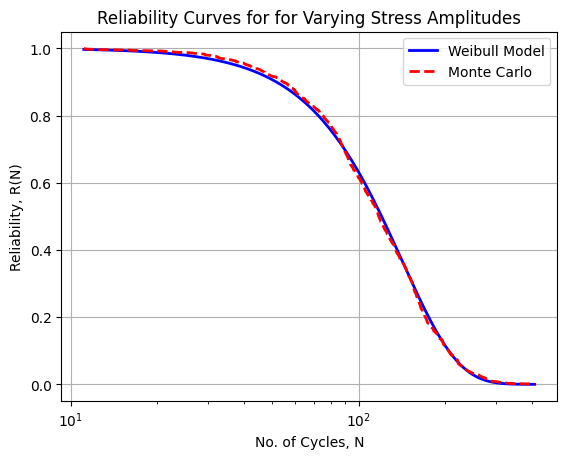

In [50]:
# plot theoretical reliability curve
plt.plot(N_vals1, R_theory1,
         color="blue",
         linewidth=2,
         label="Weibull Model")

# plot empirical reliability curve
lives_sorted1 = np.sort(lives_temp)
R_emp1 = 1 - np.arange(len(lives_temp)) / len(lives_temp)

plt.plot(lives_sorted1, R_emp1,
         linestyle="--",
         color="red",
         linewidth=2,
         label="Monte Carlo")

# axis labels
plt.title("Reliability Curves for for Varying Stress Amplitudes")
plt.xlabel("No. of Cycles, N")
plt.ylabel("Reliability, R(N)")

plt.xscale("log")
plt.legend()
plt.grid()
plt.show()

Since the Weibull reliability curve and the Monte Carlo reliability curve are very close, the probabilistic model is internally consistent and the Weibull approximation is describing the failure behavior well.